# Assignment 4 

Ian Solberg 

Professor Piao 

March 2026

---

In [1]:
import numpy as np 
import pandas as pd 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)
The beta AI model discovered a highly statistically significant positive correlation between the Inpatient_Admission_Rate and the presence of a High_Deductible_Insurance_Plan. The marketing team wishes to publish a white paper claiming that high-deductible plans cause patients to require more inpatient care due to delayed preventative treatment.

Task: Identify the omitted confounder. Draw the causal Directed Acyclic Graph (DAG) representing a "Fork" structure that explains this spurious correlation (e.g., consider unobserved patient baseline wealth or systemic poverty). Explain theoretically why regressing Admission on Insurance Type without controlling for this confounder yields a biased, mathematically contaminated predictive weight.

In [2]:
fp1 = "data/OmniCare_Clinical_Vitals.csv"
fp2 = "data/OmniCare_Telemetry_Data.csv"

df_clinical = pd.read_csv(fp1)
df_telemetry = pd.read_csv(fp2)

## Step 1.2: The Variance Inflation Factor (VIF) Audit
The dataset contains multiple continuous physiological metrics utilized to predict baseline patient risk: Weight_kg, Height_cm, BMI, Systolic_BP, and Diastolic_BP.

Task: Load the OmniCare_Clinical_Vitals.csv file. Utilizing the variance_inflation_factor function from statsmodels.stats.outliers_influence, calculate the exact VIF for all continuous features.

Deliverable: Print the resulting VIF dataframe. Identify any feature with a VIF exceeding the critical threshold of 10.0. Drop the most redundant physiological variable to relieve the multicollinearity, and recalculate the VIF matrix to prove the structural stability of the remaining feature set.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

continuous = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

def calculate_vif(df, features):
    X = df[features].copy()
    X = pd.DataFrame(sm.add_constant(X))

    vif_list = []
    for i in range(len(X.columns)):
        vif_value = variance_inflation_factor(X.values, i)
        vif_list.append(vif_value)
        
    vif_df = pd.DataFrame({"Feature": X.columns, "VIF": vif_list})
    return vif_df[vif_df["Feature"] != "const"].reset_index(drop=True)

print("--- Initial VIF Audit ---")
vif_initial = calculate_vif(df_clinical, continuous)
print(vif_initial)

high_vif = vif_initial[vif_initial["VIF"] > 10.0]
print(f"\nFeatures exceeding threshold of 10.0:\n{high_vif}")

most_redundant = high_vif.sort_values(by="VIF", ascending=False)["Feature"].values[0]
print(f"\nDropping the most redundant feature: {most_redundant}")

remaining_features = [f for f in continuous if f != most_redundant]

print("\n--- Recalculated VIF (Stable Set) ---")
vif_final = calculate_vif(df_clinical, remaining_features)
print(vif_final)

--- Initial VIF Audit ---
        Feature        VIF
0     Weight_kg  57.428058
1     Height_cm  28.419446
2           BMI  16.981232
3   Systolic_BP   4.219406
4  Diastolic_BP   4.219820

Features exceeding threshold of 10.0:
     Feature        VIF
0  Weight_kg  57.428058
1  Height_cm  28.419446
2        BMI  16.981232

Dropping the most redundant feature: Weight_kg

--- Recalculated VIF (Stable Set) ---
        Feature       VIF
0     Height_cm  1.112811
1           BMI  1.112989
2   Systolic_BP  4.219385
3  Diastolic_BP  4.219757


---

# Phase 2: Visual Forensics and The High-Cardinality Frontier


---

## Step 2.1: The Architecture of Missingness
You are provided with OmniCare_Telemetry_Data.csv, containing remote patient monitoring records from thousands of digital wearables.

Task: Utilize the missingno library to generate a missingness matrix. You will visually observe that the Continuous_Heart_Rate column contains significant, non-random gaps.

Analysis: Based on Donald Rubin’s taxonomy, if these gaps occur entirely because low-income patients systematically refuse to transmit telemetry due to the data-plan costs associated with continuous streaming, is this MCAR, MAR, or MNAR? Provide a rigorous justification and explain why mean imputation would destroy the dataset's integrity.

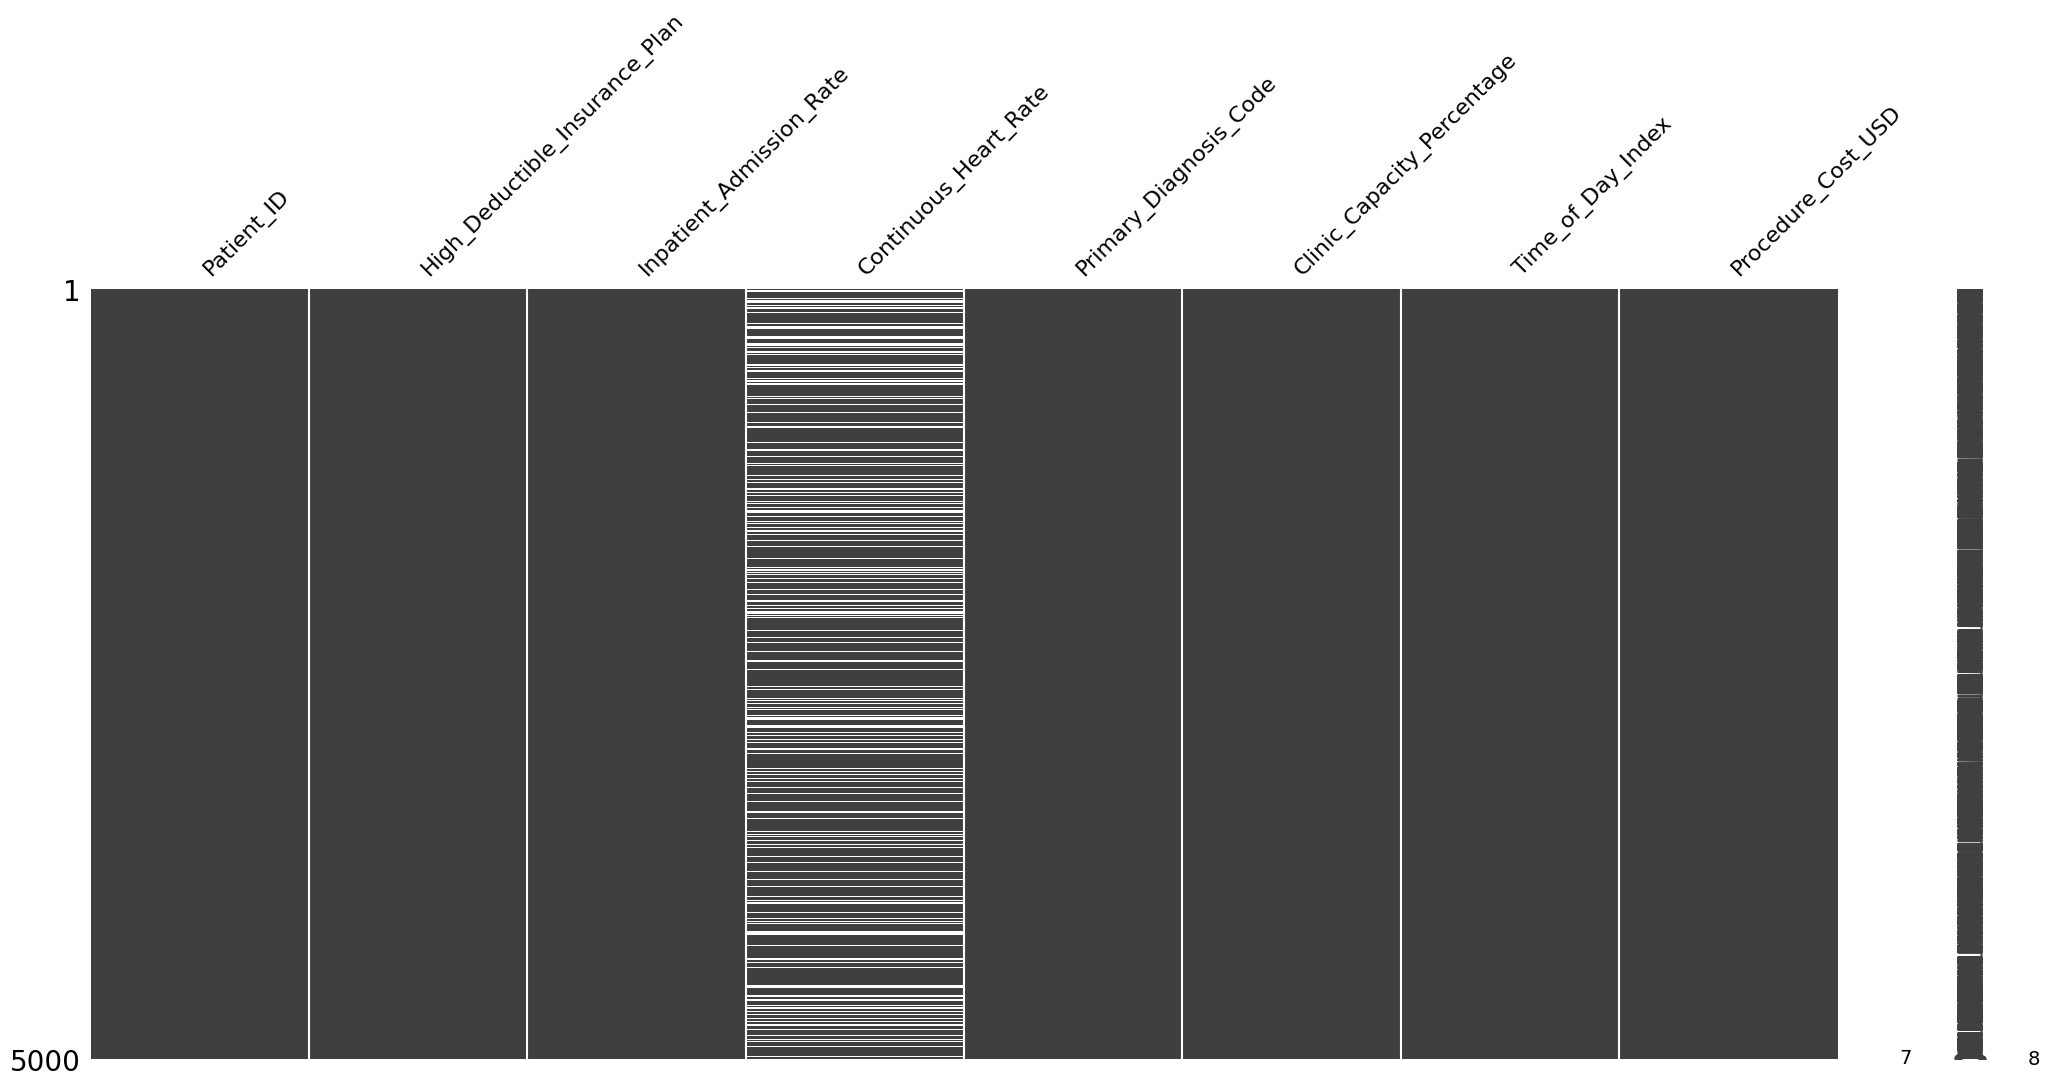

In [4]:
import missingno as msno

missing = msno.matrix(df_telemetry)

Mean imputation would pose a risk, because if the reason for missing data is non-random (in this case, low-income indivuals are the missing values), then the resulting imputation will be biased.

## Step 2.2: Escaping the Dummy Variable Trap
The dataset includes a categorical column Primary_Diagnosis_Code, containing exactly 850 distinct ICD-10 medical strings.

The Trap: A junior analyst attempts to use pd.get_dummies() to one-hot encode this column, generating 850 new binary columns. Explain the matrix algebra detailing exactly why the inclusion of a constant intercept term alongside these 850 comprehensive dummy columns creates a singular design matrix and mathematically destroys the Ordinary Least Squares estimator.

Since the introduction of 850 unique binary columns would happen because of `pd.get_dummies()` and this would prove a multi-cdollinearity issue for the model, as one column directly influences the others, i.e. if assigned one diagnosis, a patient cannot have another diagnosis, at least in this example. 

 Step 2.3: Target Encoding Implementation
Task: To prevent the Curse of Dimensionality and computational failure, you must utilize the category_encoders library. Apply a TargetEncoder to the Primary_Diagnosis_Cod]e column, mathematically mapping the high-cardinality strings to the continuous historical mean of the target variable (Procedure_Cost_USD). Print the first five rows of the newly encoded, low-dimensional continuous vector.

In [ ]:
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=["Primary_Diagnosis_Code"])

df_telemetry["Primary_Diagnosis_Code_Encoded"] = encoder.fit_transform(
    df_telemetry[["Primary_Diagnosis_Code"]],
    df_telemetry["Procedure_Cost_USD"]
)

df_telemetry["Primary_Diagnosis_Code_Encoded"].head()

0    1707.697108
1    1792.303198
2    1730.334968
3    1725.060944
4    1801.821085
Name: Primary_Diagnosis_Code_Encoded, dtype: float64

---

# Phase 3: Architecting the Prediction Engine

---

## Step 3.1: OLS Optimization via Patsy Formulas
Task: Merge your sanitized features into a final analytical dataframe. Utilize statsmodels.formula.api (specifically the smf.ols function) to define an R-style formula string regressing Procedure_Cost_USD onto your Target_Encoded_Diagnosis, Clinic_Capacity_Percentage, Time_of_Day_Index, and the sanitized vital signs from Phase 1. Fit the model and display the summary statistics table.

In [15]:
merged_df = df_telemetry.merge(df_clinical, on="Patient_ID")

formula_str = "Procedure_Cost_USD ~ Primary_Diagnosis_Code_Encoded + Clinic_Capacity_Percentage + Time_of_Day_Index + Height_cm + BMI + Systolic_BP + Diastolic_BP"

model = smf.ols(formula=formula_str, data=merged_df).fit(cov_type="HC3")
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     221.1
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          5.19e-287
Time:                        10:23:04   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

## Step 3.2: Financial Loss Quantification (RMSE)
Task: The Coefficient of Determination (R-squared) is an abstract percentage. The executive board requires risk quantification in absolute US Dollars. Utilize the statsmodels.tools.eval_measures.rmse function to calculate the Root Mean Squared Error of your fitted predictions against the ground truth.

Analysis: If the typical outpatient MRI procedure costs $1,200, and your algorithm generates an RMSE of $450, explain the catastrophic operational, financial, and regulatory risks of deploying this dynamic pricing algorithm in a live hospital environment.

In [17]:
import statsmodels.tools.eval_measures as em

predictions = model.predict(merged_df)
actuals = merged_df["Procedure_Cost_USD"]
model_rmse = em.rmse(actuals, predictions)
print(f"Model RMSE: {model_rmse:.2f}")


Model RMSE: 334.79


## Response

---

An RMSE of 334.79 indicates that our model miscalculates the price of care on average by about $335. Operational Risks (Supply & Demand Imbalance)Underpricing Demand Spikes: If the algorithm underprices a complex surgery by $335, it will trigger artificial demand. The hospital will experience equipment bottlenecks, overbooked operating rooms, and clinician burnout.Overpricing Ghost Capacity: If the algorithm overprices standard scans, patients will migrate to local competitors, leaving expensive medical machinery sitting idle.

## Step 3.3: Residual Diagnostics for Heteroscedasticity
Task: An OLS model relies on the absolute assumption of homoscedasticity (constant variance of residual errors). Extract the fitted values and the residuals from your statsmodels object. Utilize seaborn.scatterplot to map the residuals on the Y-axis against the fitted values on the X-axis.

Analysis: Visually inspect the generated scatter plot. Does the spread of the residuals fan out as the predicted procedure cost increases? What does this structural flaw indicate about the algorithm's reliability at peak surge-pricing tiers?

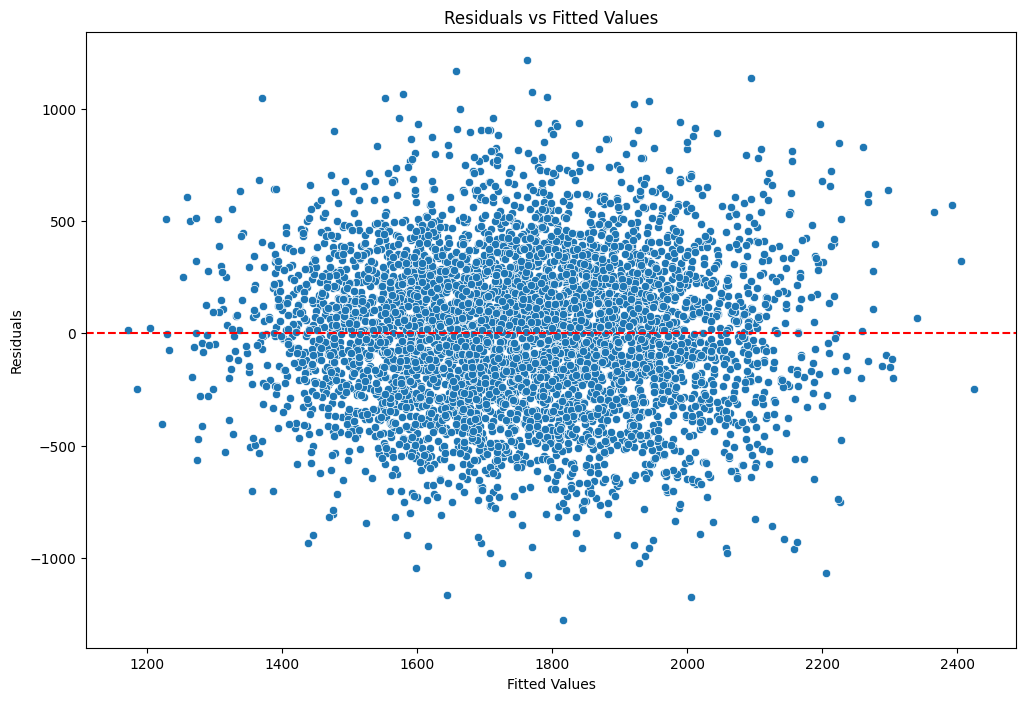

In [22]:
fitted_values = model.fittedvalues
residuals = model.resid
plt.figure(figsize=(12, 8))
sns.scatterplot(x=fitted_values, y=residuals, markers=".")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

The erros are consistent throughout, they do not obviously fan out, although there may be a slightly higher variance associated with more expensive procedures. The model is not very reliable for any range of prices.

---

# Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)

---

```
Status: Generative AI (LLMs) AUTHORIZED & REQUIRED

As a modern Tech Economist, you must command AI agents to accelerate your workflow. You are required to utilize the P.R.I.M.E. Prompting Framework (Persona, Role, Instructions, Meaning, Evaluation) to orchestrate an LLM (ChatGPT or Claude) to generate advanced statistical tests.
```

## Task 4.1: Lagrange Multiplier Test for Heteroscedasticity
Task: Construct a highly engineered P.R.I.M.E. prompt directing the AI to write a Python script executing White's Lagrange Multiplier Test for Heteroscedasticity on your exact OLS model output, utilizing the statsmodels.stats.diagnostic.het_white function.

Deliverable: Submit the exact text of your P.R.I.M.E. prompt. Execute the AI-generated code in your Colab notebook. Output the p-value of the LM test and provide a concluding sentence stating whether the null hypothesis of homoscedasticity is mathematically rejected.

## Prompt:

# P.R.I.M.E. Prompt: White's Lagrange Multiplier Test for Heteroscedasticity

---

## Persona

You are a senior econometrician with deep expertise in regression diagnostics and Python-based statistical computing using the `statsmodels` library.

## Role

Act as my statistical programming assistant. Your job is to write clean, executable Python code that performs a formal heteroscedasticity test on an OLS regression model and interprets the result.

## Instructions

1. Assume I have already estimated an OLS model using `statsmodels.api.OLS` and that the fitted model object is stored in a variable called `model`.
2. Extract the residuals and the design matrix (exogenous variables including the constant) from `model`.
3. Run White's Lagrange Multiplier Test for heteroscedasticity using `statsmodels.stats.diagnostic.het_white`.
4. Extract and clearly print the LM test statistic, the LM test p-value, the F-statistic, and the F-test p-value.
5. Using a 5% significance level, write a conditional statement that prints a concluding sentence: either rejecting the null hypothesis of homoscedasticity (meaning heteroscedasticity is detected) or failing to reject it.
6. The code must run in a Google Colab notebook with no additional setup beyond standard imports.

## Meaning

This test is critical for validating whether my OLS standard errors are reliable. If heteroscedasticity is present, my inference (t-tests, F-tests, confidence intervals) may be invalid, and I would need to switch to heteroscedasticity-robust standard errors (e.g., HC1 or HC3).

## Evaluation

The output must include the LM statistic, the p-value rounded to four decimal places, and a single plain-English concluding sentence that states whether the null hypothesis of homoscedasticity is rejected or not at the 0.05 significance level. The code should be concise, well-commented, and immediately executable.

In [24]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white

# ── Extract residuals and design matrix from the fitted OLS model ──
residuals = model.resid
exog = model.model.exog  # includes the constant if one was added

# ── Run White's LM Test for Heteroscedasticity ──
lm_stat, lm_pval, f_stat, f_pval = het_white(residuals, exog)

# ── Report results ──
print("White's Test for Heteroscedasticity")
print("=" * 40)
print(f"LM Statistic : {lm_stat:.4f}")
print(f"LM p-value   : {lm_pval:.4f}")
print(f"F-Statistic  : {f_stat:.4f}")
print(f"F p-value    : {f_pval:.4f}")
print("=" * 40)

# ── Conclusion at the 5% significance level ──
alpha = 0.05

if lm_pval < alpha:
    print(f"p-value ({lm_pval:.4f}) < {alpha}: Reject the null hypothesis of "
          f"homoscedasticity. Heteroscedasticity is detected — consider using "
          f"robust standard errors (e.g., HC1 or HC3).")
else:
    print(f"p-value ({lm_pval:.4f}) >= {alpha}: Fail to reject the null hypothesis "
          f"of homoscedasticity. No significant evidence of heteroscedasticity.")

White's Test for Heteroscedasticity
LM Statistic : 186.4282
LM p-value   : 0.0000
F-Statistic  : 5.4930
F p-value    : 0.0000
p-value (0.0000) < 0.05: Reject the null hypothesis of homoscedasticity. Heteroscedasticity is detected — consider using robust standard errors (e.g., HC1 or HC3).
